In [62]:
import torch
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [63]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [64]:
train_dir = "./train"
test_dir = "./test"

trainset = datasets.ImageFolder(root=train_dir, transform=train_transform)
testset = datasets.ImageFolder(root=test_dir, transform=test_transform)

classes = trainset.classes
print("Clases:", classes)

Clases: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [65]:
import torch
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])





train_dir = "./train"
test_dir = "./test"

trainset = datasets.ImageFolder(root=train_dir, transform=train_transform)
testset = datasets.ImageFolder(root=test_dir, transform=test_transform)

classes = trainset.classes
print("Clases:", classes)




def limit_dataset(dataset, n_samples=100, seed=42):
    np.random.seed(seed)
    targets = np.array(dataset.targets)
    indices = []
    for c in np.unique(targets):
        class_indices = np.where(targets == c)[0]
        if len(class_indices) > n_samples:
            class_indices = np.random.choice(class_indices, n_samples, replace=False)
        indices.extend(class_indices)
    np.random.shuffle(indices)
    return Subset(dataset, indices)

train_subset = limit_dataset(trainset, n_samples=50)
test_subset = limit_dataset(testset, n_samples=50)

print("Cantidad en train (subconjunto):", len(train_subset))
print("Cantidad en test (subconjunto):", len(test_subset))

Clases: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Cantidad en train (subconjunto): 350
Cantidad en test (subconjunto): 350


In [66]:
dataloader = {
    'train': DataLoader(train_subset, batch_size=32, shuffle=True),
    'val': DataLoader(test_subset, batch_size=1000, shuffle=False)
}

In [67]:
def build_model(D_in=48*48, H1=2000, H2=100, H3=500, D_out=7):
    return torch.nn.Sequential(
        torch.nn.Flatten(),
        torch.nn.Linear(D_in, H1),   
        torch.nn.ReLU(),
        torch.nn.Linear(H1, H2),    
        torch.nn.ReLU(),
        torch.nn.Linear(H2, H3),     
        torch.nn.ReLU(),
        torch.nn.Linear(H3, D_out)  
    )

In [68]:
def fit(model, dataloader, optimizer, epochs=10000, log_each=5, weight_decay=0, early_stopping=10):
    criterion = torch.nn.CrossEntropyLoss()
    l, acc = [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0

    for e in range(1, epochs+1):
        _l, _acc = [], []
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(y_pred, axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))

        # evaluación en validación
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(y_pred, axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))

        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')  # solo pesos
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1

        # early stopping
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break

        if not e % log_each:
            print(f"Epoch {e}/{epochs} | loss {l[-1]:.5f} acc {acc[-1]:.5f} | val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f}")

    # cargar mejor modelo de forma segura
    model.load_state_dict(torch.load('ckpt.pt'))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc}


In [69]:
optimizers = {
    'SGD': lambda params: torch.optim.SGD(params, lr=0.001),
    'Momentum': lambda params: torch.optim.SGD(params, lr=0.001, momentum=0.9),
    'RMSprop': lambda params: torch.optim.RMSprop(params, lr=0.001),
    'Adam': lambda params: torch.optim.Adam(params, lr=0.001)
}

histories = {}

for name, opt_func in optimizers.items():
    print(f"\nEntrenando con {name}...")
    model = build_model(D_in=48*48, H1=512, H2=256, H3=128, D_out=len(classes))
    optimizer = opt_func(model.parameters())  # ya no pasamos lr aquí
    histories[name] = fit(model, dataloader, optimizer)



Entrenando con SGD...
Mejor modelo guardado con acc 0.14286 en epoch 1
Epoch 5/10000 | loss 1.94767 acc 0.14261 | val_loss 1.94700 val_acc 0.14286
Epoch 10/10000 | loss 1.94660 acc 0.14280 | val_loss 1.94685 val_acc 0.14286
Entrenamiento detenido en epoch 11 por no mejorar en 10 epochs seguidas

Entrenando con Momentum...


C:\Users\Usuario\AppData\Local\Temp\ipykernel_2908\850019595.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


Mejor modelo guardado con acc 0.18286 en epoch 1
Mejor modelo guardado con acc 0.18857 en epoch 2
Mejor modelo guardado con acc 0.19714 en epoch 4
Epoch 5/10000 | loss 1.94491 acc 0.14508 | val_loss 1.94501 val_acc 0.19429
Epoch 10/10000 | loss 1.94164 acc 0.18542 | val_loss 1.94393 val_acc 0.18857
Entrenamiento detenido en epoch 14 por no mejorar en 10 epochs seguidas

Entrenando con RMSprop...


C:\Users\Usuario\AppData\Local\Temp\ipykernel_2908\850019595.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


Mejor modelo guardado con acc 0.18000 en epoch 1
Mejor modelo guardado con acc 0.19143 en epoch 2
Epoch 5/10000 | loss 1.82868 acc 0.27424 | val_loss 1.96583 val_acc 0.18857
Mejor modelo guardado con acc 0.21143 en epoch 6
Mejor modelo guardado con acc 0.22857 en epoch 7
Epoch 10/10000 | loss 1.64755 acc 0.38011 | val_loss 2.14338 val_acc 0.19714
Epoch 15/10000 | loss 1.39971 acc 0.43731 | val_loss 2.23129 val_acc 0.19143
Entrenamiento detenido en epoch 17 por no mejorar en 10 epochs seguidas

Entrenando con Adam...


C:\Users\Usuario\AppData\Local\Temp\ipykernel_2908\850019595.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


Mejor modelo guardado con acc 0.20286 en epoch 1
Mejor modelo guardado con acc 0.21143 en epoch 5
Epoch 5/10000 | loss 1.76650 acc 0.31364 | val_loss 2.00223 val_acc 0.21143
Mejor modelo guardado con acc 0.22286 en epoch 10
Epoch 10/10000 | loss 1.53092 acc 0.41761 | val_loss 2.11061 val_acc 0.22286
Mejor modelo guardado con acc 0.24000 en epoch 14
Epoch 15/10000 | loss 1.31721 acc 0.45720 | val_loss 2.34551 val_acc 0.22286
Mejor modelo guardado con acc 0.24571 en epoch 19
Epoch 20/10000 | loss 1.10258 acc 0.58580 | val_loss 2.65928 val_acc 0.20571
Mejor modelo guardado con acc 0.25429 en epoch 21
Epoch 25/10000 | loss 0.83388 acc 0.71080 | val_loss 3.23815 val_acc 0.23143
Mejor modelo guardado con acc 0.26000 en epoch 29
Epoch 30/10000 | loss 0.66753 acc 0.76004 | val_loss 3.42483 val_acc 0.21429
Epoch 35/10000 | loss 0.65476 acc 0.78788 | val_loss 3.88186 val_acc 0.25429
Mejor modelo guardado con acc 0.26571 en epoch 39
Epoch 40/10000 | loss 0.30900 acc 0.90019 | val_loss 4.49793 val

C:\Users\Usuario\AppData\Local\Temp\ipykernel_2908\850019595.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


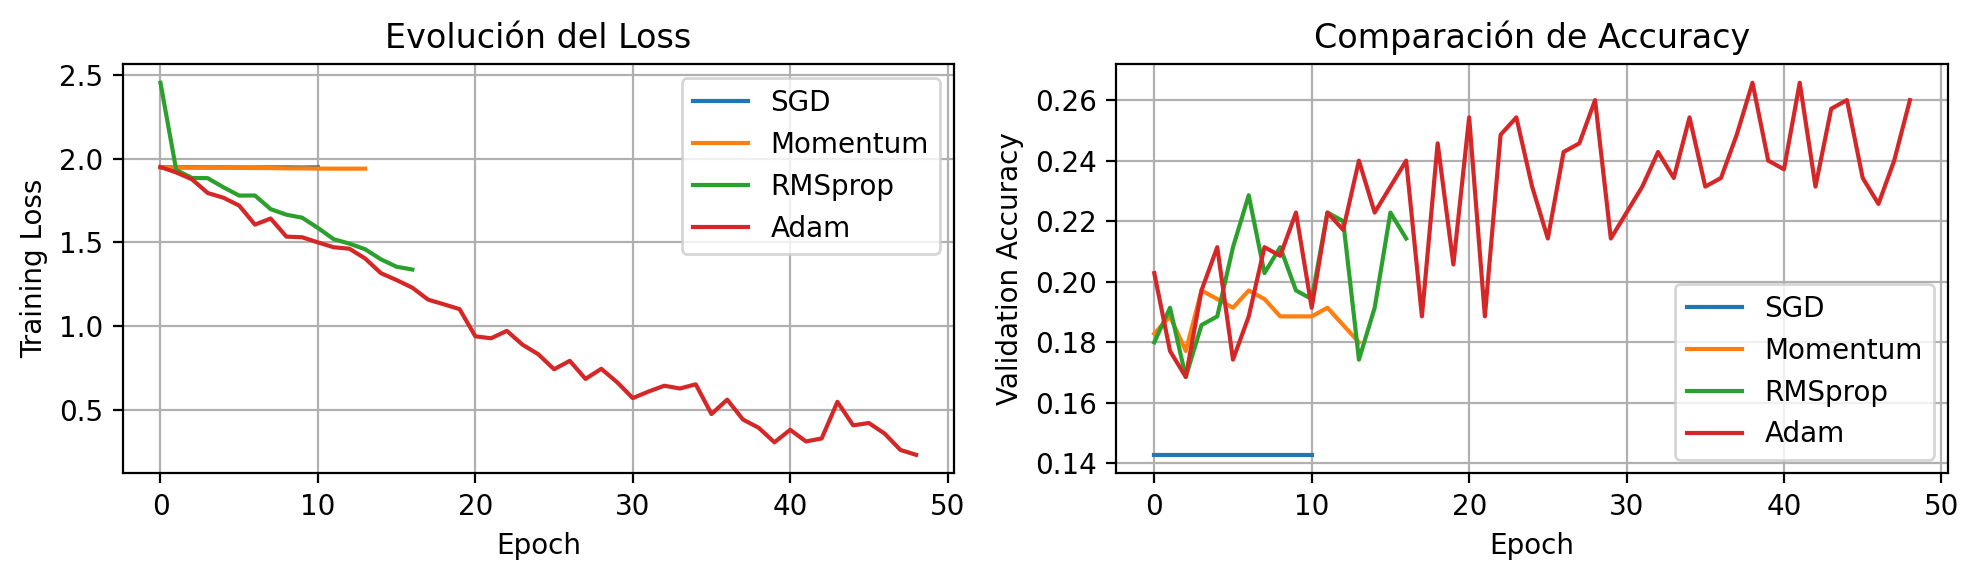

In [70]:
fig = plt.figure(dpi=200, figsize=(10,3))

# Curvas de pérdida
ax = plt.subplot(121)
for name, hist in histories.items():
    ax.plot(hist['loss'], label=name)
ax.legend()
ax.grid(True)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title("Evolución del Loss")

# Curvas de accuracy en validación
ax = plt.subplot(122)
for name, hist in histories.items():
    ax.plot(hist['val_acc'], label=name)
ax.legend()
ax.grid(True)
ax.set_ylabel('Validation Accuracy')
ax.set_xlabel('Epoch')
ax.set_title("Comparación de Accuracy")

plt.tight_layout()
plt.show()